In [42]:
# INSTALACIÓN DE DEPENDENCIAS
!pip install -q kaggle
!pip install -q tensorflow
!pip install -q seaborn

IMPORTACIÓN DE LIBRERIAS

In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


CARGAR EL DATASET

In [44]:
from google.colab import files
files.upload()  # Subir kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (1).json


In [45]:
!kaggle datasets download -d ciplab/real-and-fake-face-detection
!unzip -q real-and-fake-face-detection.zip

Dataset URL: https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection
License(s): CC-BY-NC-SA-4.0
real-and-fake-face-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
replace real_and_fake_face_detection/real_and_fake_face/training_fake/easy_100_1111.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace real_and_fake_face_detection/real_and_fake_face/training_fake/easy_101_0010.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

VERIFICAMOS EL DATASET

In [46]:
base_dir = "real_and_fake_face_detection"
print(os.listdir(base_dir))

['real_and_fake_face']


In [47]:
import os
print(os.listdir())

['.config', 'kaggle (1).json', 'real_and_fake_face_detection', 'real_and_fake_face', 'real-and-fake-face-detection.zip', 'kaggle.json', 'sample_data']


In [48]:
!mv real_and_fake_face/training_real real_and_fake_face/real

!mv real_and_fake_face/training_fake real_and_fake_face/fake

In [49]:
import os
print(os.listdir("real_and_fake_face"))
base_dir = "real_and_fake_face"

['real', 'fake']


In [50]:
real_count = len(os.listdir(os.path.join(base_dir, "real")))
fake_count = len(os.listdir(os.path.join(base_dir, "fake")))

print("Imágenes reales:", real_count)
print("Imágenes fake:", fake_count)
print("Total:", real_count + fake_count)

Imágenes reales: 1082
Imágenes fake: 961
Total: 2043


VISUALIZACIÓN INICIAL DEL DATASET

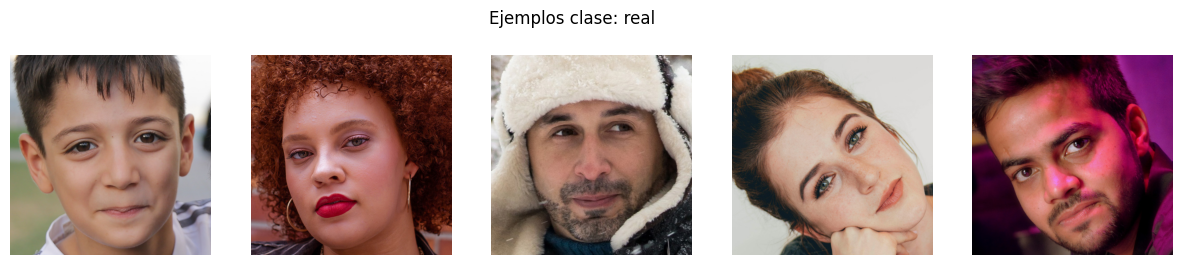

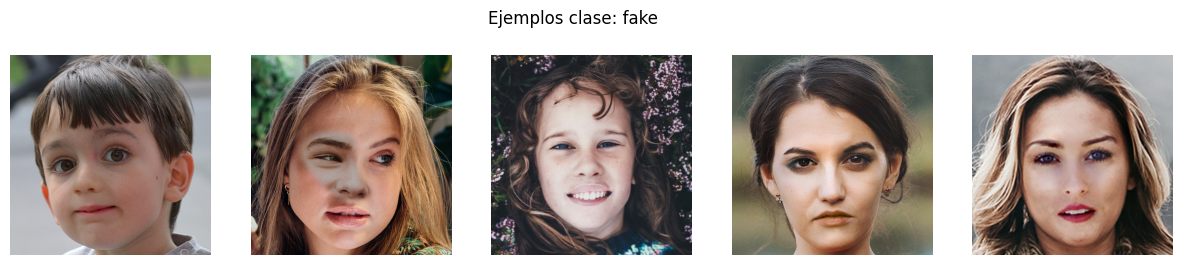

In [51]:
import random
from tensorflow.keras.preprocessing.image import load_img

def plot_samples(class_name, n=5):
    folder = os.path.join(base_dir, class_name)
    images = random.sample(os.listdir(folder), n)

    plt.figure(figsize=(15,3))
    for i, img_name in enumerate(images):
        img = load_img(os.path.join(folder, img_name))
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(f"Ejemplos clase: {class_name}")
    plt.show()

plot_samples("real")
plot_samples("fake")

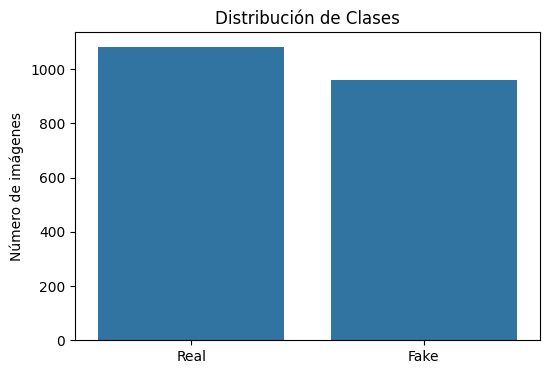

In [52]:
classes = ["Real", "Fake"]
counts = [real_count, fake_count]

plt.figure(figsize=(6,4))
sns.barplot(x=classes, y=counts)
plt.title("Distribución de Clases")
plt.ylabel("Número de imágenes")
plt.show()

PREPROCESAMIENTO

In [53]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 3266 images belonging to 2 classes.
Found 816 images belonging to 2 classes.


IMPLEMENTACIÓN MLP

In [54]:
import numpy as np
from sklearn.metrics import accuracy_score

class MLPFromScratch:

    def __init__(self, input_size, hidden_size=128, lr=0.01, lambda_l2=0.001):
        np.random.seed(42)

        self.lr = lr
        self.lambda_l2 = lambda_l2

        # Inicialización
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2/input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, 1) * np.sqrt(2/hidden_size)
        self.b2 = np.zeros((1, 1))


    # Activaciones
    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return Z > 0

    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))


    # Forward
    def forward(self, X):
        self.Z1 = X.dot(self.W1) + self.b1
        self.A1 = self.relu(self.Z1)

        self.Z2 = self.A1.dot(self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)

        return self.A2


    # Loss con L2
    def compute_loss(self, y, y_hat):
        m = y.shape[0]

        bce = - (1/m) * np.sum(
            y * np.log(y_hat + 1e-8) +
            (1 - y) * np.log(1 - y_hat + 1e-8)
        )

        l2 = (self.lambda_l2/(2*m)) * (
            np.sum(self.W1**2) + np.sum(self.W2**2)
        )

        return bce + l2


    # Backpropagation con L2
    def backward(self, X, y):
        m = X.shape[0]

        dZ2 = self.A2 - y
        dW2 = (1/m) * self.A1.T.dot(dZ2) + (self.lambda_l2/m)*self.W2
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2.dot(self.W2.T)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = (1/m) * X.T.dot(dZ1) + (self.lambda_l2/m)*self.W1
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

        # Update
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2


    # Entrenamiento con Early Stopping
    def fit(self, X_train, y_train,
            X_val=None, y_val=None,
            epochs=100, patience=10):

        y_train = y_train.reshape(-1,1)
        y_val = y_val.reshape(-1,1)

        best_loss = float('inf')
        patience_counter = 0

        for i in range(epochs):

            # Forward train
            y_hat = self.forward(X_train)
            train_loss = self.compute_loss(y_train, y_hat)

            # Backward
            self.backward(X_train, y_train)

            # Validación
            if X_val is not None:
                y_val_hat = self.forward(X_val)
                val_loss = self.compute_loss(y_val, y_val_hat)

                if val_loss < best_loss:
                    best_loss = val_loss
                    best_W1 = self.W1.copy()
                    best_W2 = self.W2.copy()
                    best_b1 = self.b1.copy()
                    best_b2 = self.b2.copy()
                    patience_counter = 0
                else:
                    patience_counter += 1

                if patience_counter >= patience:
                    print("Early stopping activado")
                    self.W1, self.W2 = best_W1, best_W2
                    self.b1, self.b2 = best_b1, best_b2
                    break

            if i % 10 == 0:
                print(f"Epoch {i}, Train Loss: {train_loss:.4f}")


    def predict(self, X):
        y_hat = self.forward(X)
        return (y_hat > 0.5).astype(int)

In [55]:
def load_data_for_mlp(generator):
    X_list = []
    y_list = []

    generator.reset()

    for i in range(len(generator)):
        X_batch, y_batch = generator[i]
        X_batch = X_batch.reshape(X_batch.shape[0], -1)

        X_list.append(X_batch)
        y_list.append(y_batch)

    X = np.vstack(X_list)
    y = np.hstack(y_list)

    return X, y

X_train_mlp, y_train_mlp = load_data_for_mlp(train_generator)
X_val_mlp, y_val_mlp = load_data_for_mlp(val_generator)

print("Shape MLP:", X_train_mlp.shape)

Shape MLP: (3266, 150528)


In [24]:
mlp_scratch = MLPFromScratch(
    input_size=input_size,
    hidden_size=256,
    lr=0.01,
    lambda_l2=0.001
)

mlp_scratch.fit(
    X_train_mlp,
    y_train_mlp,
    X_val_mlp,
    y_val_mlp,
    epochs=200,
    patience=15
)

Epoch 0, Train Loss: 0.7262
Epoch 10, Train Loss: 0.6916
Epoch 20, Train Loss: 0.6830
Epoch 30, Train Loss: 0.6824
Epoch 40, Train Loss: 0.6787
Epoch 50, Train Loss: 0.6739
Epoch 60, Train Loss: 0.6668
Epoch 70, Train Loss: 0.6671
Epoch 80, Train Loss: 0.6674
Epoch 90, Train Loss: 0.6634
Epoch 100, Train Loss: 0.6869
Early stopping activado


In [25]:
y_pred_train = mlp_scratch.predict(X_train_mlp)
y_pred_val = mlp_scratch.predict(X_val_mlp)

print("Train Accuracy:", accuracy_score(y_train_mlp, y_pred_train))
print("Validation Accuracy:", accuracy_score(y_val_mlp, y_pred_val))

Train Accuracy: 0.6209430496019596
Validation Accuracy: 0.5808823529411765


IMPLEMENTACIÓN CNN SIMPLE

In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

cnn_model = build_cnn()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 240s 4s/step - accuracy: 0.5148 - loss: 0.7896 - val_accuracy: 0.5294 - val_loss: 0.6926
Epoch 2/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 227s 4s/step - accuracy: 0.5129 - loss: 0.6937 - val_accuracy: 0.5196 - val_loss: 0.6926
Epoch 3/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 240s 5s/step - accuracy: 0.5456 - loss: 0.6912 - val_accuracy: 0.5221 - val_loss: 0.6920
Epoch 4/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 229s 4s/step - accuracy: 0.5456 - loss: 0.6901 - val_accuracy: 0.5417 - val_loss: 0.6907
Epoch 5/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 227s 4s/step - accuracy: 0.5389 - loss: 0.6911 - val_accuracy: 0.5490 - val_loss: 0.6916
Epoch 6/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 257s 5s/step - accuracy: 0.5604 - loss: 0.6879 - val_accuracy: 0.5049 - val_loss: 0.7012
Epoch 7/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 228s 4s/step - accuracy: 0.5574 - loss: 0.6922 - val_accuracy: 0.5343 - val_loss: 0.6943
Epoch 8/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 239s 5s/step - accuracy: 0.5362 - loss: 0.6860 - val_accuracy: 0.5245 - v

In [28]:
cnn_model.evaluate(val_generator)

13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.5025 - loss: 0.7278


[0.7166560888290405, 0.5049019455909729]

IMPLEMENTACIÓN CNN PROFUNDA

In [29]:
def build_cnn_deep():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

cnn_deep = build_cnn_deep()
cnn_deep.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    18,874,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,162,785 (73.10 MB)

 Trainable params: 19,162,337 (73.10 MB)

 Non-trainable params: 448 (1.75 KB)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [33]:
history_cnn_deep = cnn_deep.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 686s 13s/step - accuracy: 0.4866 - loss: 7.8319 - val_accuracy: 0.5294 - val_loss: 0.6912 - learning_rate: 5.0000e-04
Epoch 2/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 679s 13s/step - accuracy: 0.5624 - loss: 0.7017 - val_accuracy: 0.5270 - val_loss: 0.6921 - learning_rate: 5.0000e-04
Epoch 3/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 677s 13s/step - accuracy: 0.5706 - loss: 0.6875 - val_accuracy: 0.5270 - val_loss: 0.6911 - learning_rate: 5.0000e-04
Epoch 4/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 680s 13s/step - accuracy: 0.5942 - loss: 0.6775 - val_accuracy: 0.5294 - val_loss: 0.6988 - learning_rate: 5.0000e-04
Epoch 5/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 681s 13s/step - accuracy: 0.5699 - loss: 0.6814 - val_accuracy: 0.4877 - val_loss: 0.7005 - learning_rate: 5.0000e-04
Epoch 6/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 679s 13s/step - accuracy: 0.5620 - loss: 0.6858 - val_accuracy: 0.5294 - val_loss: 0.7032 - learning_rate: 5.0000e-04
Epoch 7/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 680s 13s/step - accuracy: 

IMPLEMENTACION TRANSFER LEARNING

In [34]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [35]:
history_tl = model_tl.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.5174 - loss: 0.8052 - val_accuracy: 0.4951 - val_loss: 0.7249 - learning_rate: 1.0000e-04
Epoch 2/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.5398 - loss: 0.7139 - val_accuracy: 0.4853 - val_loss: 0.7524 - learning_rate: 1.0000e-04
Epoch 3/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.5911 - loss: 0.6616 - val_accuracy: 0.5025 - val_loss: 0.7312 - learning_rate: 1.0000e-04
Epoch 4/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.5930 - loss: 0.6623 - val_accuracy: 0.5343 - val_loss: 0.7363 - learning_rate: 1.0000e-04
Epoch 5/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.6294 - loss: 0.6383 - val_accuracy: 0.5098 - val_loss: 0.7403 - learning_rate: 2.0000e-05
Epoch 6/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.6350 - loss: 0.6443 - val_accuracy: 0.4926 - val_loss: 0.7298 - learning_rate: 2.0000e-05


EVALUACIÓN Y COMPARACIÓN


===== MLP =====
              precision    recall  f1-score   support

         0.0       0.52      0.68      0.59       384
         1.0       0.61      0.45      0.52       432

    accuracy                           0.56       816
   macro avg       0.57      0.57      0.56       816
weighted avg       0.57      0.56      0.55       816



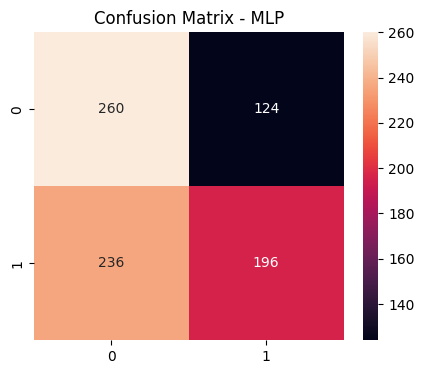

ROC-AUC: 0.5761296778549383


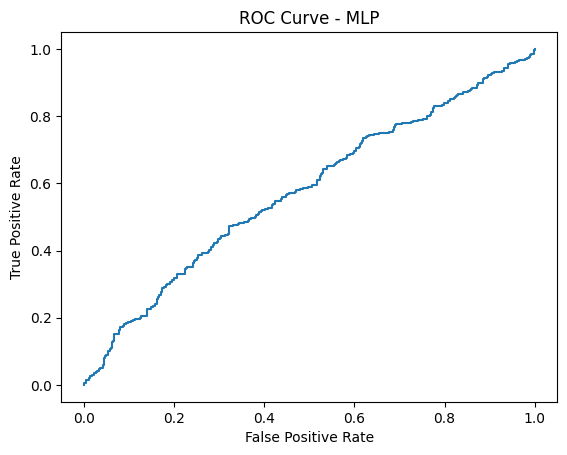

26/26 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step

===== CNN Simple =====
              precision    recall  f1-score   support

           0       0.49      0.35      0.41       384
           1       0.54      0.67      0.60       432

    accuracy                           0.52       816
   macro avg       0.51      0.51      0.50       816
weighted avg       0.52      0.52      0.51       816



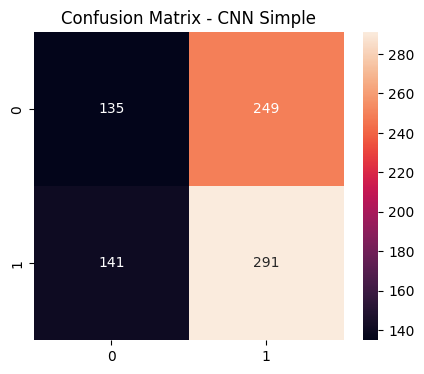

ROC-AUC: 0.5311656057098766


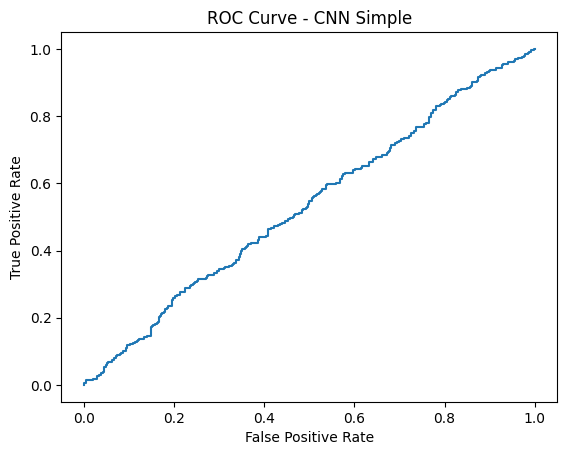

26/26 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step

===== CNN Profunda =====
              precision    recall  f1-score   support

           0       0.50      0.07      0.12       384
           1       0.53      0.94      0.68       432

    accuracy                           0.53       816
   macro avg       0.52      0.50      0.40       816
weighted avg       0.52      0.53      0.41       816



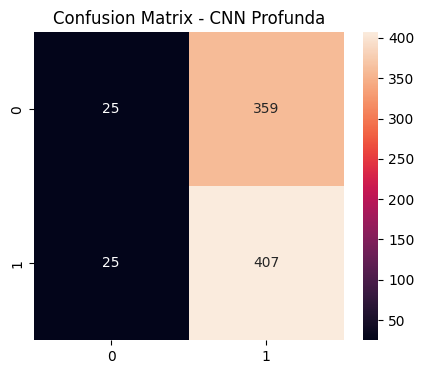

ROC-AUC: 0.48197579089506176


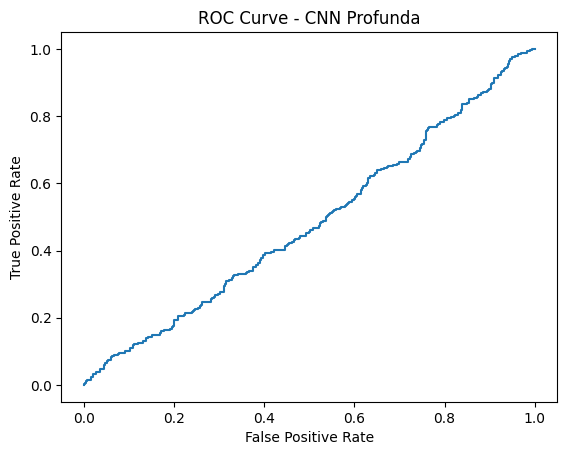

26/26 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step

===== Transfer Learning =====
              precision    recall  f1-score   support

           0       0.48      0.41      0.44       384
           1       0.54      0.61      0.57       432

    accuracy                           0.52       816
   macro avg       0.51      0.51      0.51       816
weighted avg       0.51      0.52      0.51       816



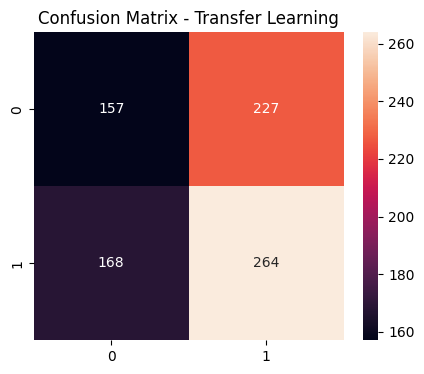

ROC-AUC: 0.5071252893518519


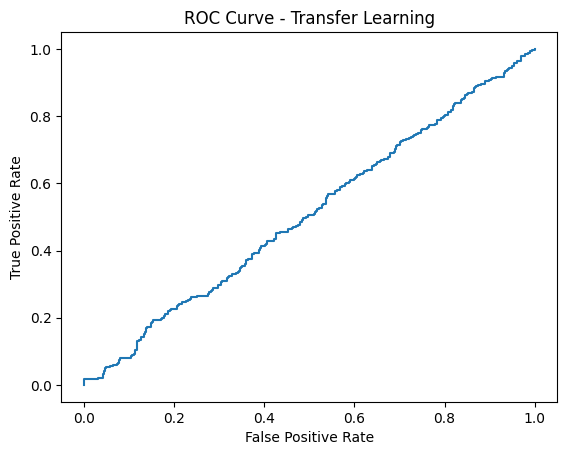

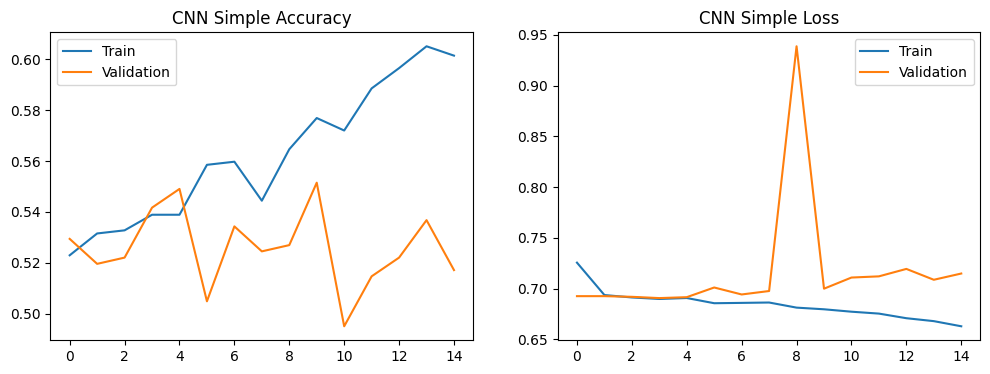

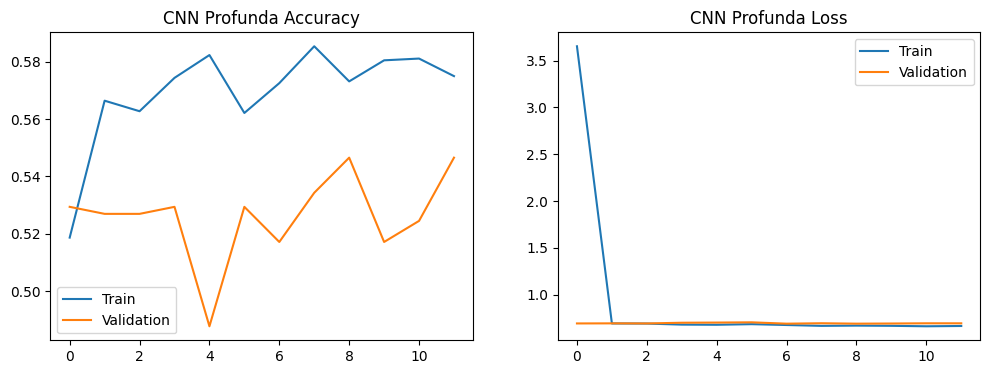

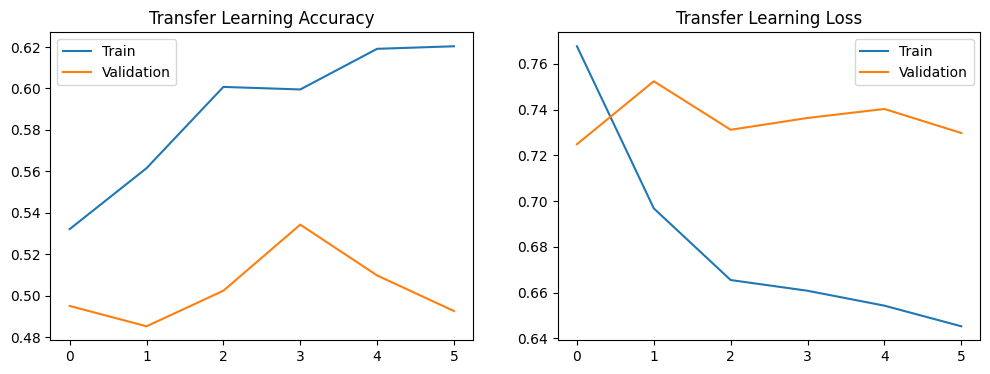


===== COMPARACIÓN FINAL =====
                   Accuracy
MLP                0.558824
CNN Profunda       0.534314
Transfer Learning  0.531863
CNN Simple         0.509804


,Accuracy
MLP,0.558824
CNN Profunda,0.534314
Transfer Learning,0.531863
CNN Simple,0.509804


In [58]:
# ================================
# EVALUACIÓN Y COMPARACIÓN
# ================================

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# -------- EVALUACIÓN MODELOS KERAS --------
def evaluate_keras_model(model, name):
    val_generator.reset()
    preds = model.predict(val_generator)
    preds_binary = (preds > 0.5).astype(int)

    y_true = val_generator.classes

    print(f"\n===== {name} =====")
    print(classification_report(y_true, preds_binary))

    cm = confusion_matrix(y_true, preds_binary)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    roc = roc_auc_score(y_true, preds)
    print("ROC-AUC:", roc)

    fpr, tpr, _ = roc_curve(y_true, preds)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()


# -------- EVALUACIÓN MLP --------
def evaluate_mlp(mlp_model, X_val, y_val):
    preds = mlp_model.forward(X_val)   # usamos forward para probabilidades
    preds_binary = (preds > 0.5).astype(int)

    print("\n===== MLP =====")
    print(classification_report(y_val, preds_binary))

    cm = confusion_matrix(y_val, preds_binary)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix - MLP")
    plt.show()

    roc = roc_auc_score(y_val, preds)
    print("ROC-AUC:", roc)

    fpr, tpr, _ = roc_curve(y_val, preds)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.title("ROC Curve - MLP")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()


# ================================
# EJECUTAR EVALUACIONES
# ================================

evaluate_mlp(mlp_scratch, X_val_mlp, y_val_mlp)

evaluate_keras_model(cnn_model, "CNN Simple")
evaluate_keras_model(cnn_deep, "CNN Profunda")
evaluate_keras_model(model_tl, "Transfer Learning")


# ================================
# GRAFICAR HISTORIAL KERAS
# ================================

def plot_history(history, title):
    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{title} Accuracy')
    plt.legend(['Train','Validation'])

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title} Loss')
    plt.legend(['Train','Validation'])

    plt.show()


plot_history(history_cnn, "CNN Simple")
plot_history(history_cnn_deep, "CNN Profunda")
plot_history(history_tl, "Transfer Learning")


# ================================
# COMPARACIÓN FINAL DE ACCURACY
# ================================

results = {}

# MLP
mlp_probs = mlp_scratch.forward(X_val_mlp)
mlp_preds = (mlp_probs > 0.5).astype(int).flatten()
mlp_acc = np.mean(mlp_preds == y_val_mlp)
results["MLP"] = mlp_acc

# CNNs
results["CNN Simple"] = cnn_model.evaluate(val_generator, verbose=0)[1]
results["CNN Profunda"] = cnn_deep.evaluate(val_generator, verbose=0)[1]
results["Transfer Learning"] = model_tl.evaluate(val_generator, verbose=0)[1]

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("\n===== COMPARACIÓN FINAL =====")
print(results_df)

results_df